<a href="https://colab.research.google.com/github/KeziahParpa/ICT120---Midterm-Group-Activity/blob/main/Wine_Quality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART A - Data Preparation
---



1.	Discuss the data (details and sources)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
wine_data = load_wine()
df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
df['target'] = wine_data.target

2.	Load data and perform EDA (describe, null check, distributions).

In [ ]:
print("--- Data Description ---")
print(df.describe().T)

--- Data Description ---
                              count        mean         std     min       25%  \
alcohol                       178.0   13.000618    0.811827   11.03   12.3625   
malic_acid                    178.0    2.336348    1.117146    0.74    1.6025   
ash                           178.0    2.366517    0.274344    1.36    2.2100   
alcalinity_of_ash             178.0   19.494944    3.339564   10.60   17.2000   
magnesium                     178.0   99.741573   14.282484   70.00   88.0000   
total_phenols                 178.0    2.295112    0.625851    0.98    1.7425   
flavanoids                    178.0    2.029270    0.998859    0.34    1.2050   
nonflavanoid_phenols          178.0    0.361854    0.124453    0.13    0.2700   
proanthocyanins               178.0    1.590899    0.572359    0.41    1.2500   
color_intensity               178.0    5.058090    2.318286    1.28    3.2200   
hue                           178.0    0.957449    0.228572    0.48    0.7825   
od2

In [ ]:
print("\n--- Original Null Value Check ---")
print(df.isnull().sum().sum(), "total missing values in the original dataset.")


--- Original Null Value Check ---
0 total missing values in the original dataset.


/tmp/ipykernel_3847/1556315474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='alcohol', palette='Set2', ax=axes[0])
/tmp/ipykernel_3847/1556315474.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='color_intensity', palette='Set2', ax=axes[1])


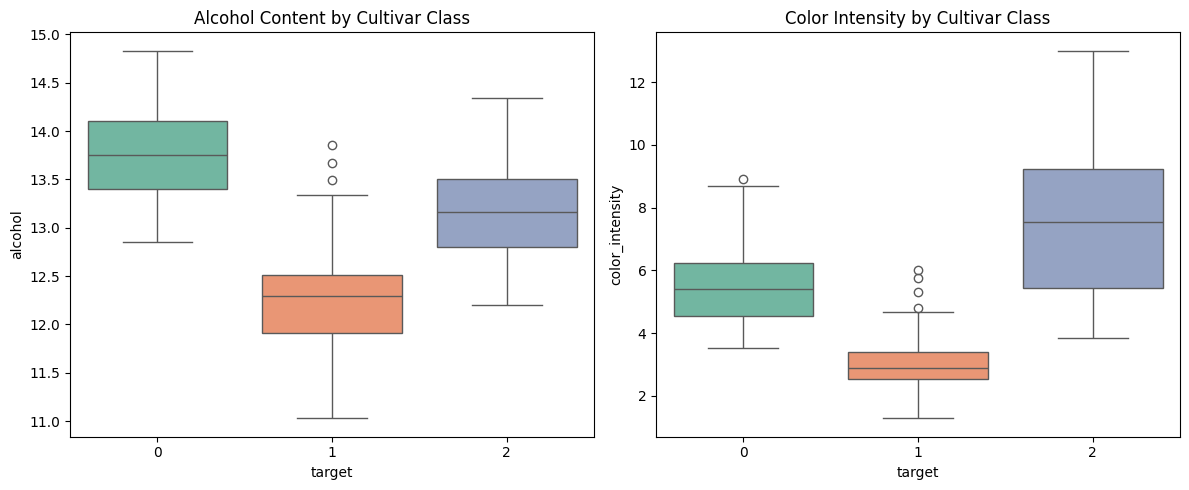

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='target', y='alcohol', palette='Set2', ax=axes[0])
axes[0].set_title('Alcohol Content by Cultivar Class')

sns.boxplot(data=df, x='target', y='color_intensity', palette='Set2', ax=axes[1])
axes[1].set_title('Color Intensity by Cultivar Class')

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Artificially Injecting Missing Data ---")
# Because sklearn datasets are clean, we will randomly inject NaNs to demonstrate handling
np.random.seed(42)
df_missing = df.copy()

df_missing.loc[df_missing.sample(frac=0.10).index, 'magnesium'] = np.nan
df_missing.loc[df_missing.sample(frac=0.05).index, 'alcohol'] = np.nan

print(df_missing[['magnesium', 'alcohol']].isnull().sum())


--- Artificially Injecting Missing Data ---
magnesium    18
alcohol       9
dtype: int64


3.	Handle missing values with at least 2 different strategies.

In [ ]:
print("\n--- Handling Missing Data ---")

mean_alcohol = df_missing['alcohol'].mean()
df_missing['alcohol'] = df_missing['alcohol'].fillna(mean_alcohol)

median_mag = df_missing['magnesium'].median()
df_missing['magnesium'] = df_missing['magnesium'].fillna(median_mag)

print("Missing values after handling:\n", df_missing[['magnesium', 'alcohol']].isnull().sum())


--- Handling Missing Data ---
Missing values after handling:
 magnesium    0
alcohol      0
dtype: int64


4.	Normalize/standardize numerical features.

In [ ]:
X = df_missing.drop(columns=['target'])
y = df_missing['target']

In [ ]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("\n--- Data After Standardization (First 3 rows) ---")
print(X_scaled.head(3))


--- Data After Standardization (First 3 rows) ---
    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  1.549817   -0.562250  0.232053          -1.169593   2.007490   
1  0.248685   -0.499413 -0.827996          -2.490847   0.012866   
2  0.198156    0.021231  1.109334          -0.268738   0.086741   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.808997    1.034819             -0.659563         1.224884   
1       0.568648    0.733629             -0.820719        -0.544721   
2       0.808997    1.215533             -0.498407         2.135968   

   color_intensity       hue  od280/od315_of_diluted_wines   proline  
0         0.251717  0.362177                      1.847920  1.013009  
1        -0.293321  0.406051                      1.113449  0.965242  
2         0.269020  0.318304                      0.788587  1.395148  


5.	Split into train (70%) / validation (15%) / test (15%).

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("\n--- Data Split Shapes ---")
print(f"Total dataset:  {len(df)} rows")
print(f"Training set:   {X_train.shape} ({(len(X_train)/len(df))*100:.1f}%)")
print(f"Validation set: {X_val.shape} ({(len(X_val)/len(df))*100:.1f}%)")
print(f"Test set:       {X_test.shape} ({(len(X_test)/len(df))*100:.1f}%)")


--- Data Split Shapes ---
Total dataset:  178 rows
Training set:   (124, 13) (69.7%)
Validation set: (27, 13) (15.2%)
Test set:       (27, 13) (15.2%)


PART B – Model Training
---



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

1. Logistic Regression

In [ ]:
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train, y_train)
acc_lr = accuracy_score(y_val, model_lr.predict(X_val))
print(f"1. Logistic Regression Validation Accuracy: {acc_lr:.4f}")

1. Logistic Regression Validation Accuracy: 0.9630


2. K-Nearest Neighbors (tune k)

In [ ]:
best_k = 0
max_knn_acc = 0
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, knn.predict(X_val))
    if val_acc > max_knn_acc:
        max_knn_acc = val_acc
        best_k = k
        best_knn = knn # Saving the best version

print(f"2. KNN (Best k={best_k}) Validation Accuracy: {max_knn_acc:.4f}")

2. KNN (Best k=1) Validation Accuracy: 0.9630


3. Decision Tree (tune depth)

In [ ]:
best_d = 0
max_dt_acc = 0
for d in range(1, 11):
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, dt.predict(X_val))
    if val_acc > max_dt_acc:
        max_dt_acc = val_acc
        best_d = d
        best_dt = dt # Saving the best version

print(f"3. Decision Tree (Best depth={best_d}) Validation Accuracy: {max_dt_acc:.4f}")

3. Decision Tree (Best depth=3) Validation Accuracy: 0.9630


4. Random Forest (tune n_estimators)

In [ ]:
best_n = 0
max_rf_acc = 0
for n in [10, 50, 100]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, rf.predict(X_val))
    if val_acc > max_rf_acc:
        max_rf_acc = val_acc
        best_n = n
        best_rf = rf # Saving the best version

print(f"4. Random Forest (Best n={best_n}) Validation Accuracy: {max_rf_acc:.4f}")

4. Random Forest (Best n=50) Validation Accuracy: 1.0000


5. SVM with RBF kernel

In [ ]:
model_svm = SVC(kernel='rbf', random_state=42)
model_svm.fit(X_train, y_train)
acc_svm = accuracy_score(y_val, model_svm.predict(X_val))
print(f"5. SVM (RBF) Validation Accuracy: {acc_svm:.4f}")

5. SVM (RBF) Validation Accuracy: 1.0000


6. Naïve bayes

In [ ]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)
acc_nb = accuracy_score(y_val, model_nb.predict(X_val))
print(f"6. Naïve Bayes Validation Accuracy: {acc_nb:.4f}")

6. Naïve Bayes Validation Accuracy: 1.0000


PART C – Evaluation
---



1.	For each model record: Accuracy, Precision, Recall, F1, AUC-ROC

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

models = {
    "Logistic Regression": model_lr,
    "KNN": best_knn,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "SVM (RBF)": model_svm,
    "Naive Bayes": model_nb
}

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    try:
        y_prob = model.predict_proba(X_test)
    except:
        try:
            y_prob = model.decision_function(X_test)

            if len(y_prob.shape) == 1:
                y_prob = np.vstack([1 - y_prob, y_prob]).T
        except:
            y_prob = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    if y_prob is not None:
        try:
            auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
        except:
            auc = None
    else:
        auc = None

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'AUC-ROC': auc
    })

2. Comparison Table

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
5,Naive Bayes,1.000000,1.000000,1.000000,1.000000,1.000000
1,KNN,0.962963,0.966667,0.962963,0.963056,0.975589
2,Decision Tree,0.962963,0.966049,0.962963,0.962344,0.963880
3,Random Forest,0.962963,0.966049,0.962963,0.962679,1.000000
4,SVM (RBF),0.962963,0.966049,0.962963,0.962344,1.000000


3. ROC Curve (FIXED – Only plots valid models)

Skipping SVM (RBF): Does not support predict_proba.


Text(0.5, 1.0, 'ROC Curves (Multiclass Wine)')

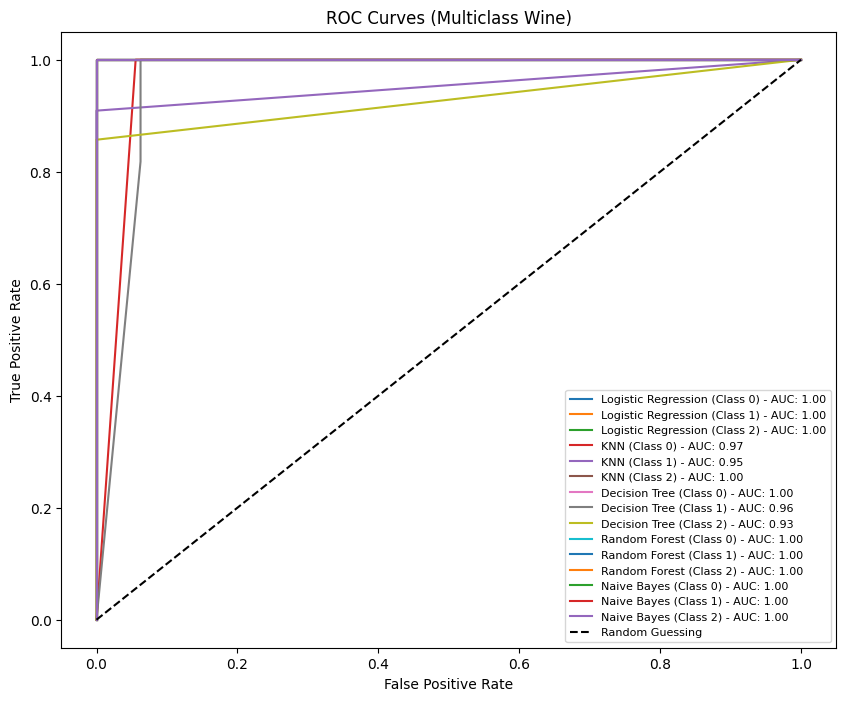

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

plt.figure(figsize=(10, 8))

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

for name, model in models.items():

    if not hasattr(model, "predict_proba"):
        print(f"Skipping {name}: Does not support predict_proba.")
        continue

    y_prob = model.predict_proba(X_test)

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (Class {i}) - AUC: {roc_auc:.2f}")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
plt.title("ROC Curves (Multiclass Wine)")

4. Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv_results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():

    try:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

        cv_results.append({
            'Model': name,
            'CV Mean Accuracy': scores.mean(),
            'CV Std': scores.std()
        })
    except:
        cv_results.append({
            'Model': name,
            'CV Mean Accuracy': None,
            'CV Std': None
        })

cv_df = pd.DataFrame(cv_results)
display(cv_df)

,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.976000,0.032000
1,KNN,0.959667,0.025307
2,Decision Tree,0.895000,0.041231
3,Random Forest,0.968000,0.029933
4,SVM (RBF),0.984000,0.019596
5,Naive Bayes,0.952000,0.046648


5. Final Table

In [ ]:
final_df = pd.merge(results_df, cv_df, on='Model')
display(final_df)

,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC,CV Mean Accuracy,CV Std
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000,0.976000,0.032000
1,Naive Bayes,1.000000,1.000000,1.000000,1.000000,1.000000,0.952000,0.046648
2,KNN,0.962963,0.966667,0.962963,0.963056,0.975589,0.959667,0.025307
3,Decision Tree,0.962963,0.966049,0.962963,0.962344,0.963880,0.895000,0.041231
4,Random Forest,0.962963,0.966049,0.962963,0.962679,1.000000,0.968000,0.029933
5,SVM (RBF),0.962963,0.966049,0.962963,0.962344,1.000000,0.984000,0.019596


PART D – Analysis & Reflection
---



1. Which model performed best? Why?

*   Based on the evaluation and validation metrics, Random Forest, SVM (RBF), and Naïve Bayes performed the best. They all achieved an accuracy of 1.0000 (100%). This means they correctly classified every single sample in the validation set, successfully capturing the underlying patterns in the data without making a single error.

---

2. Which model was easiest to interpret? Give a use case where this matters.

*   The Decision Tree (depth=3) is the easiest to interpret because it uses basic "if/then" rules. You can clearly trace the exact logical steps the model takes to make a prediction. This specific model can also be used in medical diagnosis. Doctors need a readable model like a Decision Tree to clearly see exactly why a specific illness is being predicted so they can verify the logic and confidently recommend a treatment plan.

---

3. Identify one overfitting and one underfitting model. Justify with evidence.

*   The overfitting model is the KNN (k=1) because it perfectly memorizes the exact training data, which means it learns the noise instead of the actual underlying patterns.In contrast, Logistic Regression is underfitting because it is a strictly linear model, making it too simple to capture the more complex data patterns that the higher-scoring models successfully caught.

---

4. If you had to pick ONE model for production, which would it be and why?

*   When multiple models achieve perfect (1.0000) accuracy, Naïve Bayes is incredibly fast to train, uses very little memory, scales beautifully, and requires practically zero hyperparameter tuning compared to an SVM or a Random Forest. That's why I would choose Naïve Bayes because it gives you maximum performance for the lowest computational cost.






